In [1]:
import numpy as np
import pandas as pd
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

In [2]:
ds.cells.to_pandas_dataframe(
    columns=['RNA_clusters'],
    key='I',
)['RNA_clusters'].value_counts().sort_index()

RNA_clusters
1     1261
2      699
3      670
4      318
5      299
6      252
7      246
8      143
9       25
10      15
11      12
Name: count, dtype: int64

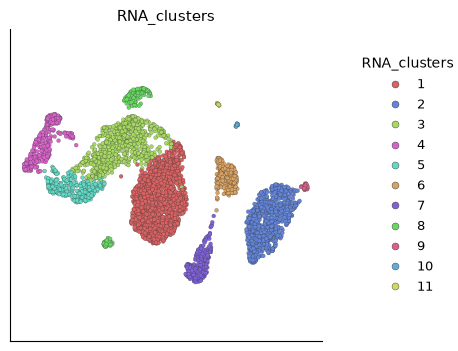

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_clusters',
)

In [4]:
markers = ds.get_markers(
    group_key='RNA_clusters',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        'feature_name',
        'score',
        'frac_exp',
        'fold_change',
        'auc',
        'p_value',
        'p_value_adjusted',
    ]
].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.65392,0.23870,15.33521,0.60948,2.476793e-109,1.832955e-107
1,TSHZ2,0.57190,0.32593,6.75262,0.63942,4.094205e-123,3.677832e-121
2,ANKRD55,0.56296,0.14750,19.15811,0.56922,4.492931e-72,1.649679e-70
3,CHRM3-AS2,0.50922,0.38303,8.24963,0.66602,6.665595e-152,8.278669e-150
4,TCEA3,0.50281,0.21015,7.79982,0.59004,7.034657e-76,2.737766e-74
5,AC005842.1,0.49610,0.15860,8.94126,0.56970,6.153527e-62,1.764876e-60
6,FHIT,0.48549,0.61856,10.59005,0.77698,9.127469e-289,4.345588e-286
7,CMTM8,0.48413,0.30531,5.11208,0.62095,8.656853e-89,4.719307e-87
8,EPHX2,0.44864,0.39017,7.32016,0.66482,2.346257e-142,2.577815e-140
9,MAN1C1,0.43633,0.31483,5.10983,0.62223,3.442119e-85,1.689477e-83


Aggregating marker values per group: 1 / 1 complete

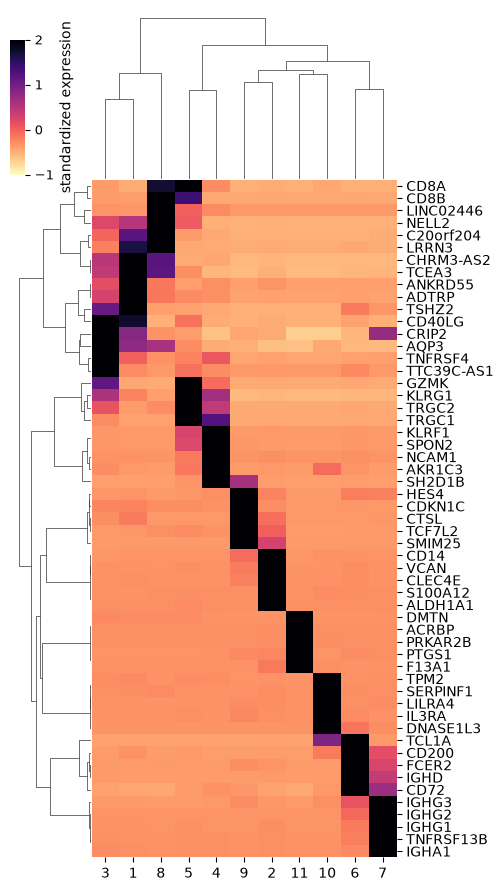

In [5]:
ds.plots.marker_heatmap(
    group_key='RNA_clusters',
    topn=5,
    figsize=(5, 9),
)

In [6]:
markers = ds.get_markers(
    group_key='RNA_clusters',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
(
    markers[markers['feature_name'].astype(str).isin(['CD14', 'MS4A1', 'CD3D'])]
    .sort_values(['feature_name', 'score'], ascending=[True, False])
    .groupby('feature_name', as_index=False)
    .head(1)[['feature_name', 'group_id', 'score', 'auc', 'frac_exp']]
)

,feature_name,group_id,score,auc,frac_exp
14285,CD14,2,0.91583,0.98424,0.96996
57188,CD3D,5,0.29026,0.81370,0.98328
71444,MS4A1,6,0.48438,0.96088,0.98810


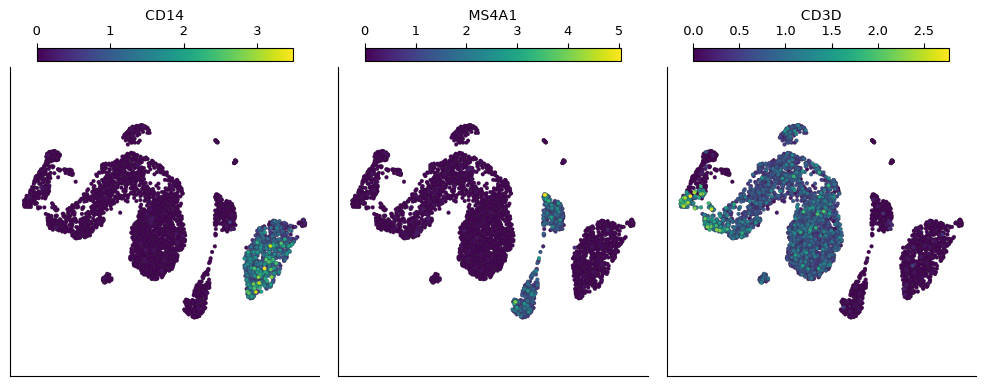

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)

In [8]:
cluster_ids = ds.cells.fetch_all('RNA_clusters')
unique = sorted(
    {str(c) for c in cluster_ids},
    key=lambda x: (0, int(x)) if x.isdigit() else (1, x),
)

label_map = {c: f'Cluster {c}' for c in unique}
for gene, name in [('CD14', 'Monocytes'), ('MS4A1', 'B cells'), ('CD3D', 'T cells')]:
    hit = markers[markers['feature_name'].astype(str) == gene]
    if hit.empty:
        continue
    cid = str(hit.sort_values('score', ascending=False).iloc[0]['group_id'])
    label_map[cid] = name

label_map

{'1': 'Cluster 1',
 '2': 'Monocytes',
 '3': 'Cluster 3',
 '4': 'Cluster 4',
 '5': 'T cells',
 '6': 'B cells',
 '7': 'Cluster 7',
 '8': 'Cluster 8',
 '9': 'Cluster 9',
 '10': 'Cluster 10',
 '11': 'Cluster 11',
 '-1': 'Cluster -1'}

In [9]:
labels = np.array([label_map[str(c)] for c in cluster_ids], dtype=object)
ds.cells.insert(column_name='cell_type', values=labels, overwrite=True)
ds.cells.to_pandas_dataframe(
    columns=['cell_type'],
    key='I',
)['cell_type'].value_counts()

cell_type
Cluster 1     1261
Monocytes      699
Cluster 3      670
Cluster 4      318
T cells        299
B cells        252
Cluster 7      246
Cluster 8      143
Cluster 9       25
Cluster 10      15
Cluster 11      12
Name: count, dtype: int64

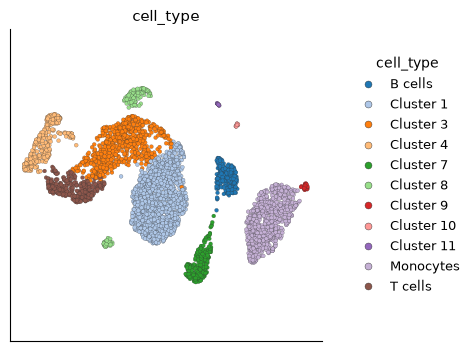

In [10]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='cell_type',
)

In [11]:
ds.smart_label(
    to_relabel='RNA_clusters',
    base_label='cell_type',
    new_col_name='leiden_by_type',
)
pd.crosstab(
    pd.Series(ds.cells.fetch('RNA_clusters'), name='RNA_clusters'),
    pd.Series(ds.cells.fetch('leiden_by_type'), name='leiden_by_type'),
)

leiden_by_type,B cellsa,Cluster 10a,Cluster 11a,Cluster 1a,Cluster 3a,Cluster 4a,Cluster 7a,Cluster 8a,Cluster 9a,Monocytesa,T cellsa
RNA_clusters,,,,,,,,,,,
1,0,0,0,1261,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,699,0
3,0,0,0,0,670,0,0,0,0,0,0
4,0,0,0,0,0,318,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,299
6,252,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,246,0,0,0,0
8,0,0,0,0,0,0,0,143,0,0,0
9,0,0,0,0,0,0,0,0,25,0,0


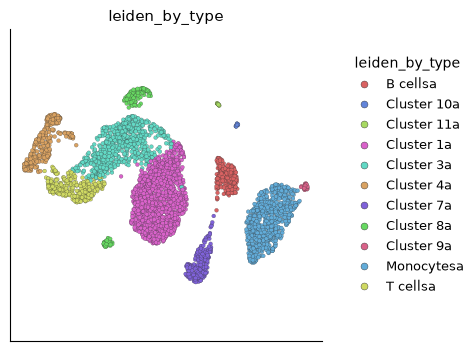

In [12]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='leiden_by_type',
)